# DELTA — Portfolio Task 2: Sentiment Analysis of Bitcoin Tweets

**Python 3.11.15** — install dependencies with `pip install -r requirements.txt`.

2 000 labelled tweets about Bitcoin (1 500 train / 500 test), binary sentiment
(`True` = positive, `False` = negative). We compare six model families on the same data
and the same protocol:

| # | Approach | Section |
|---|---|---|
| 1 | Sentiment dictionaries — VADER, Loughran-McDonald | §5 |
| 2 | TF-IDF + classifier — LogReg, LinearSVC, XGBoost | §6 |
| 3 | RNN with **own** embeddings | §7a |
| 4 | RNN with **pre-trained** embeddings (GloVe-twitter) | §7b |
| 5 | Pre-trained transformer, zero-shot — Twitter-RoBERTa, CryptoBERT | §8 |
| 6 | **Fine-tuned** transformer — DistilBERT (knowledge-distilled) | §9 |

Each model gets the preprocessing it actually needs (§3), is scored under one shared
protocol (§4), and all results are collected in a single summary table (§10).


### **1. Setup**

One-off resource downloads (NLTK corpora, ~2 s when already cached) followed by the imports
used throughout. Everything is seeded from a single `SEED`; the transformer work runs on the
GPU when one is available (`cuda` → `mps` → `cpu`).


In [1]:
import gc
import html
import os
import random
import re
import sys
import warnings

# Set before the third-party imports below, which is where these warnings are raised.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emoji
import nltk
import sklearn
import xgboost as xgb
import optuna
import gensim
import keras
import torch
import transformers

# NLTK resources — no-ops once cached locally.
for _res in ["vader_lexicon", "stopwords", "wordnet", "punkt_tab", "averaged_perceptron_tagger_eng"]:
    nltk.download(_res, quiet=True)

# Reproducibility — one seed threaded through every library we touch.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
torch.manual_seed(SEED)

# Quieter logs: we train many models and Optuna/HF are chatty by default.
optuna.logging.set_verbosity(optuna.logging.WARNING)
transformers.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()   # a weight-loading bar per from_pretrained call

# Transformer device — CUDA if present, else Apple Silicon GPU, else CPU (Tut9 idiom).
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(
    f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
    f"scikit-learn {sklearn.__version__} | xgboost {xgb.__version__} | optuna {optuna.__version__}\n"
    f"keras {keras.__version__} | gensim {gensim.__version__} | nltk {nltk.__version__} | "
    f"torch {torch.__version__} | transformers {transformers.__version__}\n"
    f"Torch device: {DEVICE}"
)


Python 3.11.15 | numpy 2.4.4 | pandas 3.0.2 | scikit-learn 1.8.0 | xgboost 3.2.0 | optuna 4.8.0
keras 3.14.0 | gensim 4.4.0 | nltk 3.9.4 | torch 2.13.0 | transformers 5.6.1
Torch device: mps


### **2. Data**

The two parquet files are already split into train (1 500) and test (500), both labelled.
`sentiment` is boolean and becomes our target `y`; `content` is the raw tweet text.


In [2]:
train = pd.read_parquet("btc_tweets_train.parquet.gzip")
test = pd.read_parquet("btc_tweets_test.parquet.gzip")

# Raw text and integer labels — the two arrays every model in this notebook consumes.
X_train_raw, y_train = train["content"].to_numpy(), train["sentiment"].astype(int).to_numpy()
X_test_raw, y_test = test["content"].to_numpy(), test["sentiment"].astype(int).to_numpy()

print(f"train {train.shape}   test {test.shape}   columns: {list(train.columns)}")
train.head(3)


train (1500, 5)   test (500, 5)   columns: ['hashtags', 'content', 'username', 'user_displayname', 'sentiment']


,hashtags,content,username,user_displayname,sentiment
tweet ID,,,,,
1641579121972236290,"[Bitcoin, Bitcoin, BTC, Bitcoin, BTC, SHIB, HO...","$Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏...",BezosCrypto,SHIB Bezos,True
1641579176171016194,"[Bitcoin, bitcoinordinals, crypto]",Alright I have my rares. Who else is grabbing ...,spartantc81,SpartanTC,True
1641579486071390208,"[BTC, SHIB, HOGE, SAITAMA, BNB, DOGE, ETH, Bab...","Bitcoin (BTC) Targets Over $100,000 as This Im...",BezosCrypto,SHIB Bezos,True


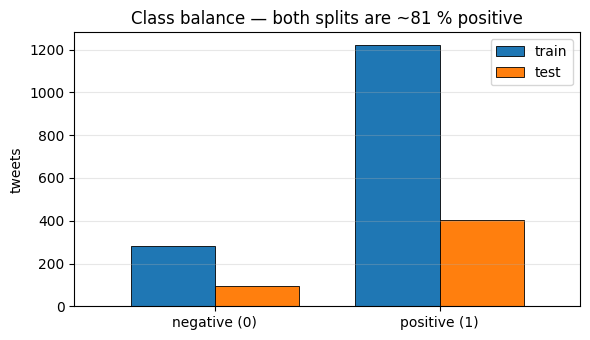

              train  test
negative (0)    280    96
positive (1)   1220   404

positive rate — train 0.8133   test 0.8080
majority-class baseline on test — accuracy 0.8080   macro-F1 0.4469


In [3]:
# Class balance, and the score a model gets for free by always predicting the majority class.
from sklearn.metrics import accuracy_score, f1_score

fig, ax = plt.subplots(figsize=(6, 3.5))
counts = pd.DataFrame(
    {"train": pd.Series(y_train).value_counts(), "test": pd.Series(y_test).value_counts()}
).sort_index()
counts.index = ["negative (0)", "positive (1)"]
counts.plot.bar(ax=ax, rot=0, width=0.75, edgecolor="black", linewidth=0.6)
ax.set_ylabel("tweets")
ax.set_title("Class balance — both splits are ~81 % positive")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

maj_acc = accuracy_score(y_test, np.ones_like(y_test))
maj_f1 = f1_score(y_test, np.ones_like(y_test), average="macro")
print(counts.to_string())
print(f"\npositive rate — train {y_train.mean():.4f}   test {y_test.mean():.4f}")
print(f"majority-class baseline on test — accuracy {maj_acc:.4f}   macro-F1 {maj_f1:.4f}")


**Why macro-F1 and not accuracy.** The classes are 4:1 imbalanced, so a model that predicts
"positive" for every tweet already scores **0.8080 accuracy** — above what several of the
benchmarks below will manage. Macro-F1 averages the two per-class F1 scores and drops that
same trivial model to **0.4469**, so it actually rewards getting the 96 negative tweets right.
We therefore report macro-F1 as the headline metric, with balanced accuracy, the negative-class
precision/recall/F1, ROC-AUC and PR-AUC alongside, and keep the majority-class row in the final
table as an explicit floor.


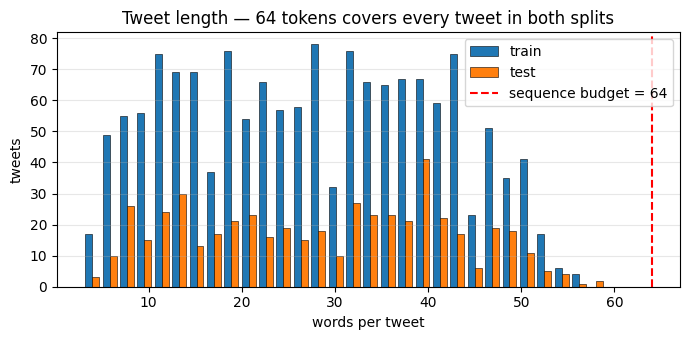

        train   test
count  1500.0  500.0
mean     27.5   28.4
std      13.4   13.5
min       3.0    4.0
50%      28.0   29.5
90%      46.0   46.0
99%      53.0   54.0
max      57.0   59.0


In [4]:
# Tweet length drives the sequence budget for the RNNs (§7) and the transformers (§8-9).
lengths = pd.DataFrame(
    {"train": pd.Series(X_train_raw).str.split().str.len(),
     "test": pd.Series(X_test_raw).str.split().str.len()}
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist([lengths["train"].dropna(), lengths["test"].dropna()], bins=30, label=["train", "test"],
        edgecolor="black", linewidth=0.4)
ax.axvline(64, color="red", linestyle="--", label="sequence budget = 64")
ax.set_xlabel("words per tweet")
ax.set_ylabel("tweets")
ax.set_title("Tweet length — 64 tokens covers every tweet in both splits")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(lengths.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())


In [5]:
# Integrity checks before we commit to a protocol: leakage, duplicates, missing values.
print(f"missing values          : train {train.isna().to_numpy().sum()}   test {test.isna().to_numpy().sum()}")
print(f"duplicate tweet texts   : train {train['content'].duplicated().sum()}   test {test['content'].duplicated().sum()}")
print(f"tweet IDs shared        : {len(set(train.index) & set(test.index))}")
print(f"tweet texts shared      : {len(set(train['content']) & set(test['content']))}")
print(f"usernames shared        : {len(set(train['username']) & set(test['username']))}"
      f"  (of {train['username'].nunique()} train / {test['username'].nunique()} test users)")


missing values          : train 0   test 0
duplicate tweet texts   : train 0   test 0
tweet IDs shared        : 0
tweet texts shared      : 0
usernames shared        : 155  (of 1012 train / 404 test users)


**We model `content` only.** No tweet ID or tweet text is shared between the splits, but **155 of
the 404 test users also appear in train**. Feeding `username` or `user_displayname` to a model
would let it memorise which accounts post positively rather than read the text, inflating test
scores in a way that would not survive on new users. `hashtags` is dropped for a different reason —
it is a redundant copy of the `#`-tokens already inside `content`.

Sequence budget: the longest tweet is 59 words, so **64 tokens** truncates nothing. That figure is
reused for the RNN sequence length (§7) and the transformer `max_length` (§8–9).


In [6]:
def show_examples(label: int, n: int = 4, width: int = 150) -> None:
    """Print n training tweets carrying the given label, flattened to one line each."""
    rng = np.random.default_rng(SEED)
    idx = rng.choice(np.flatnonzero(y_train == label), size=n, replace=False)
    for i in idx:
        print(" •", re.sub(r"\s+", " ", X_train_raw[i])[:width])

print("POSITIVE (1)")
show_examples(1)
print("\nNEGATIVE (0)")
show_examples(0)


POSITIVE (1)
 • How wild is it that we are so right about #Bitcoin What a freaking incredible blessing
 • $BKKT Ask The Expert: What Consumer Research Says About Crypto Pathways | Bakkt #StocksInFocus Related to #Bitcoin #BTC https://t.co/hBL6UQwiab
 • #Crypto #Bitcoin New to crypto? How to find a coin/tokens contract on: 🟠Dextools 🟢Coin Gecko 🔵Coin Market Cap ⚪️Crypto Rank https://t.co/uabpoYLkwy Cr
 • 🔥 https://t.co/8kWqgEeplL Crypto Loan #USDT #BTC #ETH #PROS Trade Now! 👉 https://t.co/aqyT2igXkb Share your feedback &amp; Get a Bonus! 👉 https://t.co

NEGATIVE (0)
 • 58% of the population buys lottery tickets on a regular basis, but only 0.5% have bought #Bitcoin What the heck is wrong with people?
 • #Bitcoin has no limit on transaction amount on its network. These restrictions show #BTC is digital cash and can’t be stopped. Quite unfortunate to se
 • $BTC.D #Bitcoin still sucking the life out of altcoins https://t.co/Hn5abYmirD
 • SILK ROAD #BITCOIN WAS SIEZED @ &gt;60K US GOV SELLS

**What the two classes actually contain.** The negatives carry explicit negative markers
("*What the heck is wrong with people?*", "*Quite unfortunate*", "*sucking the life out of
altcoins*", "*-60% LOSS*"). The positives, however, include tweets with no sentiment at all —
a Bakkt research announcement or a "how to find a contract address". **The positive class is effectively "not negative"**, absorbing neutral,
promotional and informational tweets.

Two consequences for the pipeline:

- A lexicon that fires on *positive* words will under-predict the positive class, because most
  positive tweets contain no positive words — they are simply not negative. The decision
  threshold has to be calibrated rather than left at its natural midpoint (§4).
- Off-the-shelf sentiment models are trained on a positive/neutral/negative distinction that
  this dataset does not use, so we should expect them to need recalibration, and expect
  fine-tuning on in-domain labels to help (§8 vs. §9).

The samples also show what the text layer must handle: HTML entities (`&amp;`), `https://t.co`
URLs, `@mentions`, `#hashtags`, `$cashtags` and emoji.


### **3. Preprocessing — one variant per model family**

A single shared pipeline would sabotage at least one model, because the four families disagree
about what counts as signal and what counts as noise:

| variant | used by | keeps | removes / rewrites |
|---|---|---|---|
| `clean_lexicon` | VADER, Loughran-McDonald (§5) | emoji, ALL-CAPS, `!!!`, negations — VADER *scores* all of these | URLs, `@mentions`, HTML entities; `#`/`$` sigils dropped, words kept |
| `clean_bow` | TF-IDF (§6) | lemmas, negation words, emoji as `emo_*` tokens, a `cashtag` marker | word order, casing, stopwords, punctuation, numbers |
| `clean_rnn` | both RNNs (§7) | word order, negations, `<url>`/`<user>`/`<hashtag>`/`<cashtag>` placeholders | casing, raw URLs, inflection left intact for the embedding |
| `clean_transformer` | zero-shot + fine-tuned (§8–9) | very nearly everything, cashtags included | URLs → `http`, `@mentions` → `@user` |

`clean_transformer` is deliberately the lightest: it reproduces the normalisation
Twitter-RoBERTa was itself trained with, and Tut9 found transformers score *better* on
near-raw text than on aggressively cleaned text — their subword tokenizers already handle
casing, emoji and rare words.

Hashtags and cashtags both get an explicit marker token rather than having their sigil silently
deleted, because the *density* of ticker mentions carries signal on its own — the next cell
quantifies that before we commit to it.


In [7]:
# Do cashtags ($BTC, $BKKT) carry signal, or are they just noise we can strip?
_CASH = re.compile(r"\$([A-Za-z][A-Za-z0-9._]{0,9})\b")
_n_cash = pd.Series([len(_CASH.findall(t)) for t in X_train_raw])

print(f"tweets with >=1 cashtag : {(_n_cash > 0).mean():.1%}"
      f"   distinct tickers: {len({m.upper() for t in X_train_raw for m in _CASH.findall(t)})}")
print(f"mean cashtags — positive: {_n_cash[y_train == 1].mean():.2f}"
      f"   negative: {_n_cash[y_train == 0].mean():.2f}")
for lo, hi, lab in [(0, 0, "0 cashtags"), (1, 2, "1-2 cashtags"), (3, 99, ">=3 cashtags")]:
    m = _n_cash.between(lo, hi)
    print(f"  P(positive | {lab:12s}) = {y_train[m].mean():.3f}   (n={m.sum()})")


tweets with >=1 cashtag : 26.6%   distinct tickers: 239
mean cashtags — positive: 0.63   negative: 0.31
  P(positive | 0 cashtags  ) = 0.779   (n=1101)
  P(positive | 1-2 cashtags) = 0.904   (n=314)
  P(positive | >=3 cashtags) = 0.918   (n=85)


**Cashtags are signal, so we keep them.** The probability of a positive label rises
monotonically with ticker density — 0.779 with no cashtag, 0.904 with one or two, 0.918 with
three or more — which fits the §2 observation that promotional multi-ticker tweets land in the
positive class. Stripping the `$` silently would merge `$BTC` with `#BTC` and `BTC` and discard
that, so `clean_bow` and `clean_rnn` emit an explicit marker token instead.


In [8]:
# Shared building blocks for all four variants.
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
CASHTAG_RE = re.compile(r"\$([A-Za-z][A-Za-z0-9._]{0,9})\b")  # $BTC, $BKKT, $BTC.D
NUMBER_RE = re.compile(r"\b\d[\d,.]*\b")
WS_RE = re.compile(r"\s+")
# Split CamelCase at lower->upper and at the tail of an acronym: "AltCoinSeason" -> "Alt Coin Season".
CAMEL_RE = re.compile(r"(?<=[a-z0-9])(?=[A-Z])|(?<=[A-Z])(?=[A-Z][a-z])")


def split_camel(s: str) -> str:
    """Break a CamelCase hashtag body into separate words; all-lowercase bodies are untouched."""
    return CAMEL_RE.sub(" ", s)


def squeeze(s: str) -> str:
    """Collapse runs of whitespace and trim."""
    return WS_RE.sub(" ", s).strip()


In [9]:
def clean_lexicon(t: str) -> str:
    """Light clean for the dictionary models — keeps emoji, casing and punctuation intact."""
    t = html.unescape(t)
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(lambda m: " " + split_camel(m.group(1)), t)  # drop '#', keep the word
    t = CASHTAG_RE.sub(lambda m: " " + m.group(1), t)               # drop '$', keep the ticker
    return squeeze(t)


def clean_transformer(t: str) -> str:
    """Twitter-RoBERTa's own normalisation: URLs and mentions become placeholders, nothing else."""
    t = html.unescape(t)
    t = URL_RE.sub("http", t)
    t = MENTION_RE.sub("@user", t)
    return squeeze(t)


In [10]:
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

LEMMATIZER = WordNetLemmatizer()
TAG_MAP = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
# Negations must survive stopword removal — "not bullish" and "bullish" are opposite labels.
NEGATIONS = {"no", "not", "nor", "never", "none", "cannot", "don", "aren", "couldn", "didn",
             "doesn", "hadn", "hasn", "haven", "isn", "shouldn", "wasn", "weren", "won", "wouldn"}
BOW_STOPWORDS = set(stopwords.words("english")) - NEGATIONS


def clean_bow(t: str) -> str:
    """Bag-of-words clean: lemmatised content words, emoji as `emo_*`, tickers as `cashtag <sym>`."""
    t = html.unescape(t)
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(lambda m: " " + split_camel(m.group(1)), t)
    t = CASHTAG_RE.sub(lambda m: " cashtag " + m.group(1), t)  # marker keeps ticker density visible
    t = emoji.demojize(t, delimiters=(" emo_", " "))
    t = t.lower().replace("n't", " not ")
    t = NUMBER_RE.sub(" ", t)
    t = re.sub(r"[^a-z0-9_ ]", " ", t)
    tokens = [w for w in t.split() if w not in BOW_STOPWORDS and len(w) > 1]
    # POS-tag the whole tweet at once: faster than Tut4's per-word call, and context-aware.
    return " ".join(
        LEMMATIZER.lemmatize(w, TAG_MAP.get(tag[0].upper(), wordnet.NOUN))
        for w, tag in nltk.pos_tag(tokens)
    )


In [11]:
def clean_rnn(t: str) -> str:
    """Sequence clean for the RNNs, following GloVe-twitter's own token conventions."""
    t = html.unescape(t)
    t = URL_RE.sub(" <url> ", t)
    t = MENTION_RE.sub(" <user> ", t)
    t = HASHTAG_RE.sub(lambda m: " <hashtag> " + split_camel(m.group(1)), t)
    t = CASHTAG_RE.sub(lambda m: " <cashtag> " + m.group(1), t)
    t = emoji.demojize(t, delimiters=(" ", " ")).replace("_", " ")  # 🚀 -> "rocket", a real GloVe word
    t = t.lower().replace("n't", " not ")
    t = NUMBER_RE.sub(" <number> ", t)
    t = re.sub(r"([!?])", r" \1 ", t)          # '!' and '?' are sentiment-bearing GloVe tokens
    t = re.sub(r"[^a-z0-9<>!?\s]", " ", t)     # drop remaining punctuation, keep the placeholders
    return squeeze(t)


In [12]:
# One tweet through all four variants, to make the differences concrete.
demo = X_train_raw[0]
for name, fn in [("raw", lambda t: t), ("clean_lexicon", clean_lexicon),
                 ("clean_bow", clean_bow), ("clean_rnn", clean_rnn),
                 ("clean_transformer", clean_transformer)]:
    print(f"{name:18s} {squeeze(fn(demo))[:170]}")


raw                $Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏 #Bitcoin TO $100,000 WHETHER YOU BELIEVE OR NOT‼️💯🙏 $BTC #Bitcoin #BTC #Bitcoin #BTC #SHIB #HOGE #SAITAMA #BNB #DOGE #ETH #
clean_lexicon      Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏 Bitcoin TO $100,000 WHETHER YOU BELIEVE OR NOT‼️💯🙏 BTC Bitcoin BTC Bitcoin BTC SHIB HOGE SAITAMA BNB DOGE ETH Baby Floki Alt
clean_bow          cashtag bitcoin sooner think emo_double_exclamation_mark emo_hundred_points emo_folded_hands bitcoin whether believe not emo_double_exclamation_mark emo_hundred_points em
clean_rnn          <cashtag> bitcoin to <number> sooner than you think double exclamation mark hundred points folded hands <hashtag> bitcoin to <number> whether you believe or not double ex
clean_transformer  $Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏 #Bitcoin TO $100,000 WHETHER YOU BELIEVE OR NOT‼️💯🙏 $BTC #Bitcoin #BTC #Bitcoin #BTC #SHIB #HOGE #SAITAMA #BNB #DOGE #ETH #


In [13]:
import time

# Apply every variant once, up front; §5-§9 just pick the arrays they need.
_t0 = time.time()
TEXTS = {}
for variant, fn in [("lexicon", clean_lexicon), ("bow", clean_bow),
                    ("rnn", clean_rnn), ("transformer", clean_transformer)]:
    TEXTS[variant] = (np.array([fn(t) for t in X_train_raw]),
                      np.array([fn(t) for t in X_test_raw]))
print(f"preprocessed 2000 tweets x 4 variants in {time.time() - _t0:.1f}s\n")

summary = pd.DataFrame(
    {variant: {
        "mean tokens (train)": round(np.mean([len(s.split()) for s in tr]), 1),
        "vocabulary (train)": len({w for s in tr for w in s.split()}),
        "empty after cleaning": int((tr == "").sum() + (te == "").sum()),
    } for variant, (tr, te) in TEXTS.items()}
)
print(summary.to_string())


preprocessed 2000 tweets x 4 variants in 1.5s

                      lexicon     bow     rnn  transformer
mean tokens (train)      26.9    18.7    35.8         27.5
vocabulary (train)    11107.0  5287.0  6148.0      11684.0
empty after cleaning      0.0     0.0     0.0          0.0


### **4. Evaluation protocol**

Every model in §5–§9 is scored the same way, so the final table compares models rather than
methodologies. Two tiers:

**Tier 1 — hyperparameter selection.** A single stratified 80/20 split of the training set,
`fit` (1 200) / `val` (300). Used where a 5× cost is not worth paying: the RNN config sweep and
the DistilBERT sweep.

**Tier 2 — the reported result.** Stratified 5-fold CV over all 1 500 training tweets:

```
for each fold:   train on 1 200  →  score the held-out 300     ⇒  out-of-fold (OOF) scores
threshold    =   argmax macro-F1 over the 1 500 OOF scores
CV macro-F1  =   mean ± std of the per-fold macro-F1 at that threshold
test score   =   refit on all 1 500, predict the 500 test tweets ONCE at the frozen threshold
```

**Why calibrate the threshold at all.** At 4:1 imbalance the natural cut-off (0.5 for a
probability, 0 for a lexicon polarity) is not the macro-F1 optimum, and §2 showed the positive
class also absorbs neutral tweets — so a model's score distribution is shifted relative to the
labels. Calibrating on **1 500 OOF scores (280 negatives)** rather than a single 300-tweet
validation split (56 negatives) makes that one scalar far less noisy.

**Why a CV column at all.** The test set holds only 96 negative tweets, so differences in test
macro-F1 below roughly ±0.03 are not distinguishable. The per-fold standard deviation tells us
which gaps in the final table are real.

*Caveat: hyperparameters are chosen on the Tier-1 split rather than nested inside the Tier-2
folds, so CV macro-F1 is mildly optimistic. Fully nested CV would multiply the runtime without
changing the ranking. The test column is unaffected — it is never used for any fitting.*


In [14]:
from sklearn.model_selection import StratifiedKFold, train_test_split

N_SPLITS = 5

# Tier 1 — one stratified split, used only for hyperparameter selection.
idx_fit, idx_val = train_test_split(
    np.arange(len(y_train)), test_size=0.2, random_state=SEED, stratify=y_train
)
# Tier 2 — the folds every reported model is scored on. Materialised once so all models share them.
FOLDS = list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
             .split(np.zeros(len(y_train)), y_train))

print(f"Tier 1  fit {len(idx_fit)} ({y_train[idx_fit].mean():.3f} pos) | "
      f"val {len(idx_val)} ({y_train[idx_val].mean():.3f} pos)")
print(f"Tier 2  {N_SPLITS} folds, validation sizes {[len(v) for _, v in FOLDS]}, "
      f"negatives per fold {[int((y_train[v] == 0).sum()) for _, v in FOLDS]}")


Tier 1  fit 1200 (0.813 pos) | val 300 (0.813 pos)
Tier 2  5 folds, validation sizes [300, 300, 300, 300, 300], negatives per fold [56, 56, 56, 56, 56]


In [15]:
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             precision_score, recall_score, roc_auc_score)


def tune_threshold(y_true: np.ndarray, scores: np.ndarray) -> float:
    """Cut-off maximising macro-F1; searched over score quantiles, never on test data."""
    cand = np.unique(scores)
    if len(cand) > 500:
        cand = np.unique(np.quantile(scores, np.linspace(0.005, 0.995, 500)))
    f1s = [f1_score(y_true, (scores > t).astype(int), average="macro") for t in cand]
    return float(cand[int(np.argmax(f1s))])


def binary_metrics(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> dict:
    """All reported metrics for one model at a fixed threshold; 'neg' = the minority class."""
    pred = (scores > threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced acc": balanced_accuracy_score(y_true, pred),
        "Precision (neg)": precision_score(y_true, pred, pos_label=0, zero_division=0),
        "Recall (neg)": recall_score(y_true, pred, pos_label=0, zero_division=0),
        "F1 (neg)": f1_score(y_true, pred, pos_label=0, zero_division=0),
        "Macro-F1": f1_score(y_true, pred, average="macro"),
        "ROC-AUC": roc_auc_score(y_true, scores),
        # PR-AUC on the minority class: flip labels and scores so 'negative' is the positive class.
        "PR-AUC (neg)": average_precision_score(1 - y_true, -scores),
    }


In [16]:
RESULTS: dict[str, dict] = {}


def cv_oof(fit_predict, X: np.ndarray, y: np.ndarray = y_train) -> np.ndarray:
    """Out-of-fold scores over the Tier-2 folds; `fit_predict(X_tr, y_tr, X_va)` returns val scores."""
    oof = np.zeros(len(y), dtype=float)
    for tr, va in FOLDS:
        oof[va] = np.asarray(fit_predict(X[tr], y[tr], X[va]), dtype=float).ravel()
    return oof


def record(name: str, oof: np.ndarray, test_scores: np.ndarray, threshold: float | None = None) -> None:
    """Calibrate on OOF, score the test set once, and store the result in RESULTS under `name`."""
    thr = tune_threshold(y_train, oof) if threshold is None else threshold
    oof_pred = (oof > thr).astype(int)
    per_fold = np.array([f1_score(y_train[va], oof_pred[va], average="macro") for _, va in FOLDS])

    RESULTS[name] = {
        "CV macro-F1": per_fold.mean(),
        "CV std": per_fold.std(),
        **binary_metrics(y_test, np.asarray(test_scores, dtype=float), thr),
        "Threshold": thr,
        "_oof": oof,
        "_test": np.asarray(test_scores, dtype=float),
    }
    r = RESULTS[name]
    print(f"{name:28s} CV macro-F1 {r['CV macro-F1']:.4f} ± {r['CV std']:.4f}   |   "
          f"test macro-F1 {r['Macro-F1']:.4f}   ROC-AUC {r['ROC-AUC']:.4f}   thr {thr:+.3f}")


# The floor: always predict the majority class. Constant score, so no threshold to calibrate.
record("Majority class", np.ones(len(y_train)), np.ones(len(y_test)), threshold=0.5)


Majority class               CV macro-F1 0.4485 ± 0.0000   |   test macro-F1 0.4469   ROC-AUC 0.5000   thr +0.500


### **5. Benchmark 1 — sentiment dictionaries**

A crypto tweet sits away from any lexicon's home territory along two independent axes: its
**register** (short, capitalised, emoji-laden social text) and its **domain** (finance). We pick
one lexicon matching each axis, so the comparison answers which mismatch is the more expensive:

- **VADER** (`nltk.sentiment.vader`) — *register match, domain mismatch*. Built for social media,
  and rule-based on top of its word list: it boosts for ALL-CAPS, scales with repeated `!`, and
  flips polarity after a negation — the three cues §3 deliberately preserved for this model.
- **Loughran-McDonald** (`pysentiment2.LM`) — *domain match, register mismatch*. Built for annual
  reports, where "liability" or "volatility" are negative in a way general-purpose lists miss.

Tut7's Harvard IV-4 matches neither axis, which is why we replace it here. Neither lexicon is
fitted, so their out-of-fold scores are simply their scores on the training tweets — only the
threshold is calibrated.


In [17]:
import pysentiment2 as ps
from nltk.sentiment.vader import SentimentIntensityAnalyzer

X_lex_train, X_lex_test = TEXTS["lexicon"]

sia = SentimentIntensityAnalyzer()
vader_train = np.array([sia.polarity_scores(t)["compound"] for t in X_lex_train])
vader_test = np.array([sia.polarity_scores(t)["compound"] for t in X_lex_test])

lm = ps.LM()  # LM loads cleanly on pandas 3.x; only HIV4 needs Tut7's dtype='category' workaround
lm_train = np.array([lm.get_score(lm.tokenize(t))["Polarity"] for t in X_lex_train])
lm_test = np.array([lm.get_score(lm.tokenize(t))["Polarity"] for t in X_lex_test])

print(f"LM lexicon size — {len(lm._posset)} positive / {len(lm._negset)} negative words")
print(f"tweets scored exactly 0 (no lexicon word matched) — "
      f"VADER {np.mean(vader_train == 0):.1%}   LM {np.mean(lm_train == 0):.1%}")
print(f"correlation between the two scores: {np.corrcoef(vader_train, lm_train)[0, 1]:.3f}")


LM lexicon size — 140 positive / 893 negative words
tweets scored exactly 0 (no lexicon word matched) — VADER 32.1%   LM 62.8%
correlation between the two scores: 0.368


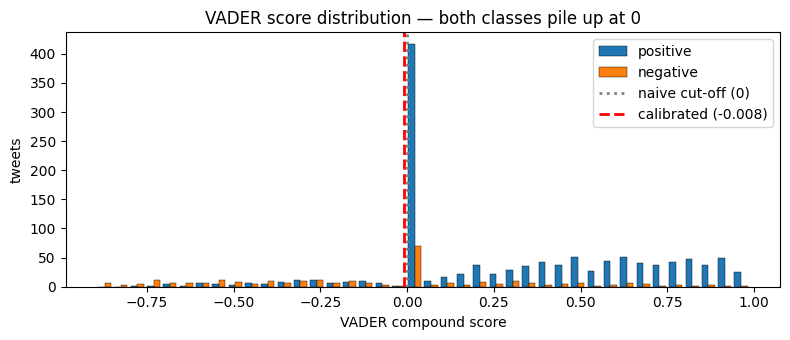

VADER                macro-F1  naive 0.5497  ->  calibrated 0.7038  (+0.1540, threshold -0.008)
Loughran-McDonald    macro-F1  naive 0.3440  ->  calibrated 0.6491  (+0.3052, threshold -0.200)


In [18]:
# What the calibrated cut-off buys over the lexicon's natural one (polarity > 0).
thr_vader = tune_threshold(y_train, vader_train)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist([vader_train[y_train == 1], vader_train[y_train == 0]], bins=40, stacked=False,
        label=["positive", "negative"], edgecolor="black", linewidth=0.3)
ax.axvline(0.0, color="grey", linestyle=":", linewidth=2, label="naive cut-off (0)")
ax.axvline(thr_vader, color="red", linestyle="--", linewidth=2, label=f"calibrated ({thr_vader:+.3f})")
ax.set_xlabel("VADER compound score")
ax.set_ylabel("tweets")
ax.set_title("VADER score distribution — both classes pile up at 0")
ax.legend()
plt.tight_layout()
plt.show()

for name, s in [("VADER", vader_train), ("Loughran-McDonald", lm_train)]:
    t = tune_threshold(y_train, s)
    naive = f1_score(y_train, (s > 0).astype(int), average="macro")
    cal = f1_score(y_train, (s > t).astype(int), average="macro")
    print(f"{name:20s} macro-F1  naive {naive:.4f}  ->  calibrated {cal:.4f}  "
          f"(+{cal - naive:.4f}, threshold {t:+.3f})")


In [19]:
record("Lexicon — VADER", vader_train, vader_test)
record("Lexicon — Loughran-McDonald", lm_train, lm_test)


Lexicon — VADER              CV macro-F1 0.7036 ± 0.0269   |   test macro-F1 0.7008   ROC-AUC 0.7658   thr -0.008
Lexicon — Loughran-McDonald  CV macro-F1 0.6475 ± 0.0413   |   test macro-F1 0.6408   ROC-AUC 0.6809   thr -0.200


**Register beats domain.** VADER **0.7036 ± 0.0269** vs Loughran-McDonald **0.6475 ± 0.0413**.
LM scores exactly zero on **62.8 %** of tweets against VADER's 32.1 % — an annual-report
vocabulary largely misses crypto Twitter. At correlation 0.37 the two read different features
rather than one being a weaker copy of the other.

Calibration is worth +0.154 macro-F1 for VADER but **+0.305** for LM, which carries 893 negative
words to 140 positive ones and so over-predicts negative at a cut-off of 0. Both calibrated
thresholds sit just below zero, and CV and test agree to within 0.007 for both.


### **6. Benchmark 2 — TF-IDF + classifier**

The task leaves the classifier open, so rather than assert one we search three families on
identical features and let the numbers decide:

- `LogisticRegression` and `LinearSVC`, both `class_weight='balanced'` — the classical choice
  for sparse text;
- `XGBClassifier` with `scale_pos_weight` — the tree benchmark, matching Tut4's XGB-vs-Logit
  comparison.

**Features.** A `FeatureUnion` of word 1–2 grams and `char_wb` 3–5 grams. The word view alone is
brittle on a corpus this small: a token such as `emo_rocket` or a split hashtag fragment may
occur in only a handful of the 1 200 training documents — too few occurrences to estimate a
reliable weight for that token. Character n-grams pool the evidence instead of fragmenting it,
because related tokens share substrings: `emo_rocket` and `emo_fire` both contain `emo_`,
`bitcoin` and `bitcoins` overlap almost entirely.

**Search.** Optuna TPE maximising calibrated macro-F1 over 3-fold out-of-fold scores computed
**inside the Tier-1 `fit` split only**, so the Tier-2 folds are never seen during selection. We
run **one study per family**.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

X_bow_train, X_bow_test = TEXTS["bow"]
POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost's scale_pos_weight
FAMILIES = ["logreg", "linsvc", "xgb"]


def build_tfidf_pipeline(p: dict) -> Pipeline:
    """Word + character TF-IDF feeding one of three classifier families, per the params dict."""
    features = FeatureUnion([
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, p["word_ngram"]),
                                 min_df=p["min_df"], sublinear_tf=p["sublinear_tf"],
                                 max_features=p["max_features"])),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, p["char_ngram"]),
                                 min_df=p["min_df"], sublinear_tf=p["sublinear_tf"],
                                 max_features=p["max_features"])),
    ])
    if p["clf"] == "logreg":
        clf = LogisticRegression(C=p["C"], class_weight="balanced", max_iter=2000, random_state=SEED)
    elif p["clf"] == "linsvc":
        # max_iter well above the default 1000: liblinear does not converge on 20k sparse features.
        clf = LinearSVC(C=p["C"], class_weight="balanced", max_iter=20000, random_state=SEED)
    else:
        clf = XGBClassifier(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"], learning_rate=p["eta"],
            subsample=p["subsample"], colsample_bytree=p["colsample"],
            scale_pos_weight=POS_WEIGHT, tree_method="hist", eval_metric="logloss",
            random_state=SEED, n_jobs=4,
        )
    return Pipeline([("features", features), ("clf", clf)])


def tfidf_scores(pipe: Pipeline, X_va: np.ndarray) -> np.ndarray:
    """Continuous score for either classifier type — probability, or SVM decision function."""
    if hasattr(pipe[-1], "predict_proba"):
        return pipe.predict_proba(X_va)[:, 1]
    return pipe.decision_function(X_va)


In [21]:
from optuna.samplers import TPESampler

TRIALS_PER_FAMILY = 20
# 3 inner folds, not 5: the search only has to *rank* configurations.
INNER_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


def suggest_tfidf_params(trial: optuna.Trial, family: str) -> dict:
    """Vectoriser geometry plus the hyperparameters of one fixed classifier family."""
    p = {
        "clf": family,
        "word_ngram": trial.suggest_int("word_ngram", 1, 2),
        "char_ngram": trial.suggest_int("char_ngram", 4, 5),
        "min_df": trial.suggest_int("min_df", 1, 5),
        "max_features": trial.suggest_categorical("max_features", [5000, 10000, 20000]),
        "sublinear_tf": trial.suggest_categorical("sublinear_tf", [False, True]),
    }
    if family == "xgb":
        p.update(
            n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
            max_depth=trial.suggest_int("max_depth", 3, 6),
            eta=trial.suggest_float("eta", 0.02, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample=trial.suggest_float("colsample", 0.3, 1.0),
        )
    else:
        p["C"] = trial.suggest_float("C", 1e-2, 1e2, log=True)
    return p


def tfidf_objective(trial: optuna.Trial, family: str) -> float:
    """Calibrated macro-F1 over inner out-of-fold scores — the same quantity §10 reports."""
    p = suggest_tfidf_params(trial, family)
    X_f, y_f = X_bow_train[idx_fit], y_train[idx_fit]
    oof = np.zeros(len(y_f))
    for tr, va in INNER_CV.split(X_f, y_f):
        pipe = build_tfidf_pipeline(p).fit(X_f[tr], y_f[tr])
        oof[va] = tfidf_scores(pipe, X_f[va])
    return f1_score(y_f, (oof > tune_threshold(y_f, oof)).astype(int), average="macro")


In [22]:
# Long-running cell: 3 families x 20 trials x 3 folds.
studies, best_params = {}, {}
_t0 = time.time()

for family in FAMILIES:
    _t1 = time.time()
    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
    study.optimize(lambda t, f=family: tfidf_objective(t, f), n_trials=TRIALS_PER_FAMILY)
    studies[family] = study
    best_params[family] = suggest_tfidf_params(
        optuna.trial.FixedTrial(study.best_params), family
    )
    print(f"{family:8s} {TRIALS_PER_FAMILY} trials in {time.time() - _t1:5.1f}s   "
          f"best calibrated macro-F1 {study.best_value:.4f}")

print(f"\ntotal search time {(time.time() - _t0) / 60:.1f} min")


logreg   20 trials in  15.2s   best calibrated macro-F1 0.7245
linsvc   20 trials in  15.4s   best calibrated macro-F1 0.7231
xgb      20 trials in 116.8s   best calibrated macro-F1 0.6524

total search time 2.5 min


In [23]:
# Which family won, and with what configuration.
comparison = pd.DataFrame([
    {"family": f,
     "inner-CV macro-F1": round(studies[f].best_value, 4),
     "n features": best_params[f]["max_features"],
     "config": {k: (round(v, 4) if isinstance(v, float) else v)
                for k, v in best_params[f].items()
                if k not in ("clf", "max_features", "word_ngram", "char_ngram")}}
    for f in FAMILIES
]).sort_values("inner-CV macro-F1", ascending=False)

print(comparison.to_string(index=False))


family  inner-CV macro-F1  n features                                                                                                                             config
logreg             0.7245       20000                                                                                  {'min_df': 1, 'sublinear_tf': False, 'C': 7.8756}
linsvc             0.7231       20000                                                                                   {'min_df': 1, 'sublinear_tf': True, 'C': 0.7742}
   xgb             0.6524       20000 {'min_df': 2, 'sublinear_tf': False, 'n_estimators': 300, 'max_depth': 4, 'eta': 0.0329, 'subsample': 0.9042, 'colsample': 0.5503}


In [24]:
# Tier-2: 5-fold CV over all 1500 with each family's winning config, then refit and score test.
TFIDF_LABELS = {"logreg": "TF-IDF + LogReg", "linsvc": "TF-IDF + LinearSVC",
                "xgb": "TF-IDF + XGBoost"}


def tfidf_fit_predict(p: dict):
    """Build a fit_predict closure for cv_oof from a fixed parameter dict."""
    def _fp(X_tr, y_tr, X_va):
        return tfidf_scores(build_tfidf_pipeline(p).fit(X_tr, y_tr), X_va)
    return _fp


tfidf_final = {}
for family in FAMILIES:
    p = best_params[family]
    oof = cv_oof(tfidf_fit_predict(p), X_bow_train)
    tfidf_final[family] = build_tfidf_pipeline(p).fit(X_bow_train, y_train)  # refit on all 1500
    record(TFIDF_LABELS[family], oof, tfidf_scores(tfidf_final[family], X_bow_test))


TF-IDF + LogReg              CV macro-F1 0.7282 ± 0.0405   |   test macro-F1 0.7738   ROC-AUC 0.8855   thr +0.592
TF-IDF + LinearSVC           CV macro-F1 0.7325 ± 0.0337   |   test macro-F1 0.7873   ROC-AUC 0.8817   thr +0.119
TF-IDF + XGBoost             CV macro-F1 0.6796 ± 0.0216   |   test macro-F1 0.6741   ROC-AUC 0.7980   thr +0.491


**Linear beats trees.** LinearSVC **0.7325 ± 0.0337** vs XGBoost **0.6796 ± 0.0216** — a 0.053
gap, roughly 1.5× the larger fold spread, and it holds on test (0.787 vs 0.674). Plausibly the
feature shape: ~20 000 sparse columns from 1 200 documents, where a tree splits on one column at
a time while a linear margin sums evidence across all of them. XGBoost also cost 122 s against
the linear models' 17 s.

LogReg and LinearSVC land 0.004 apart and swap ranks between the inner and Tier-2 CV — not
distinguishable at this sample size, so both stay in the table. The best TF-IDF model now leads
VADER (0.7325 vs 0.7036), but by less than the combined spread.


*Aside: what does the winning linear model actually key on?
Its largest coefficients are cheap to read off, and they let us check whether the §3
preprocessing choices earned their place. Bracketed entries are character n-grams rather
than whole words.*


In [25]:
# Whichever linear model scored higher under the Tier-2 CV we just ran.
best_linear = max(["logreg", "linsvc"], key=lambda f: RESULTS[TFIDF_LABELS[f]]["CV macro-F1"])
best_linear_pipe = tfidf_final[best_linear]
print(f"inspecting: {TFIDF_LABELS[best_linear]}\n")

names = np.array(best_linear_pipe.named_steps["features"].get_feature_names_out())
coefs = best_linear_pipe.named_steps["clf"].coef_.ravel()
order = np.argsort(coefs)


def _fmt(name: str) -> str:
    """Render a feature name, bracketing character n-grams to tell them from words."""
    kind, feat = name.split("__", 1)
    return feat if kind == "word" else f"[{feat}]"


top = pd.DataFrame({
    "most negative": [_fmt(n) for n in names[order[:15]]],
    "weight (neg)": coefs[order[:15]].round(3),
    "most positive": [_fmt(n) for n in names[order[-15:]][::-1]],
    "weight (pos)": coefs[order[-15:]][::-1].round(3),
})
print(top.to_string(index=False))


inspecting: TF-IDF + LinearSVC

                  most negative  weight (neg)      most positive  weight (pos)
                            not        -1.002              right         0.511
                           dump        -0.916             [righ]         0.483
                            bad        -0.752            bullish         0.441
                          [ot ]        -0.726                btc         0.438
                          [ no]        -0.723           sell btc         0.436
                         [ not]        -0.710                one         0.427
                          [not]        -0.696 understand bitcoin         0.423
                         [not ]        -0.690      money bitcoin         0.417
                         [bear]        -0.687         emo_rocket         0.414
                          [ du]        -0.682               plan         0.412
emo_police_car_light government        -0.614               pump         0.402
                   s

*Two §3 choices show up here: **`not`** is the strongest negative feature (−1.00) and sits in
NLTK's default stopword list, so the negation carve-out mattered; and `emo_rocket` ranks among
the top positives, so keeping emoji as `emo_*` tokens earned its place. The character n-grams
trail the same tokens (`[ no]`, `[ not]`, `[not ]`), acting as a redundancy net rather than new
signal.*


### **7. Benchmark 3 — RNN classifiers**

Two recurrent classifiers, one trained on embeddings learned from scratch and one on pre-trained
vectors. Both are **tuned independently**, so each row is the best that embedding source achieved
rather than a controlled ablation — the task asks for these as benchmarks, so handicapping one
with the other's architecture would understate it.

```
TextVectorization(max_tokens=V, output_sequence_length=64)
  → Embedding(V, 100, mask_zero=True)          ← 7a random init | 7b GloVe-twitter
  → SpatialDropout1D → Bidirectional(LSTM(units, return_sequences=True))
  → MaskedGlobalMaxPooling1D → Dropout → Dense(64, relu) → Dropout → Dense(1, sigmoid)
```

- **7a — own embeddings.** Randomly initialised, trained end-to-end on the tweets.
- **7b — pre-trained embeddings.** `glove-twitter-100`, trained on 2 B tweets, so it matches the
  register and already contains `<url>`, `<user>` and `<hashtag>` — the exact tokens §3 emits.
  Its search carries one extra knob, whether the embedding stays frozen.

**Search.** Optuna TPE over width, dropout, spatial dropout, learning rate and batch size, scored
on the Tier-1 validation split — one study per variant.

Two guards against leakage: the vectoriser is re-adapted inside every fold, and early stopping
watches AUC on a stratified 15 % slice carved from that fold's *training* data — never the fold's
validation split.


In [26]:
SEQ_LEN = 64          # §2: the longest tweet is 59 words, so nothing is truncated
EMB_DIM = 100         # matches glove-twitter-100, so 7a and 7b have identical capacity
VOCAB_SIZE = 8000     # §3 reported a 6 148-word RNN vocabulary; this caps it with room to spare
MAX_EPOCHS = 30

X_rnn_train, X_rnn_test = TEXTS["rnn"]
# Balanced class weights: without them the 4:1 imbalance drives the net to predict all-positive.
CLASS_WEIGHT = {0: len(y_train) / (2 * (y_train == 0).sum()),
                1: len(y_train) / (2 * (y_train == 1).sum())}
print(f"class weights: {{0: {CLASS_WEIGHT[0]:.3f}, 1: {CLASS_WEIGHT[1]:.3f}}}")


class MaskedGlobalMaxPooling1D(keras.layers.Layer):
    """Max-pool over real tokens only — Keras' GlobalMaxPooling1D discards the padding mask."""

    def call(self, inputs, mask=None):
        if mask is not None:
            inputs = keras.ops.where(keras.ops.expand_dims(mask, -1), inputs, -1e9)
        return keras.ops.max(inputs, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def compute_mask(self, inputs, mask=None):
        return None


def make_vectorizer(texts: np.ndarray) -> keras.layers.TextVectorization:
    """Adapt a whitespace vectoriser on one fold's training texts (§3 already standardised them)."""
    vec = keras.layers.TextVectorization(
        max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN, standardize=None
    )
    vec.adapt(texts)
    return vec


def build_embedding_matrix(vec: keras.layers.TextVectorization, kv) -> np.ndarray:
    """Pre-trained rows aligned to this fold's vocabulary; OOV rows get distinct random vectors.

    Leaving OOV rows at zero would make every unknown token identical and invisible to a frozen
    embedding, which would bias the frozen-vs-fine-tuned choice in 7b's search.
    """
    vocab = vec.get_vocabulary()
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0.0, float(kv.vectors.std()), (VOCAB_SIZE, EMB_DIM)).astype("float32")
    matrix[0] = 0.0  # padding row
    hits = 0
    for i, word in enumerate(vocab[:VOCAB_SIZE]):
        if word in kv:
            matrix[i] = kv[word]
            hits += 1
    build_embedding_matrix.coverage = hits / max(len(vocab) - 2, 1)  # exclude '' and [UNK]
    return matrix


def build_rnn(embedding_matrix: np.ndarray | None = None, trainable_emb: bool = True,
              units: int = 64, dropout: float = 0.5, spatial: float = 0.3,
              lr: float = 1e-3) -> keras.Model:
    """Bi-LSTM with a max-pooled head; the embedding is random unless a matrix is supplied."""
    embedding = keras.layers.Embedding(
        VOCAB_SIZE, EMB_DIM, mask_zero=True, trainable=trainable_emb,
        embeddings_initializer=("uniform" if embedding_matrix is None
                                else keras.initializers.Constant(embedding_matrix)),
    )
    model = keras.Sequential([
        keras.Input(shape=(SEQ_LEN,), dtype="int32"),
        embedding,
        keras.layers.SpatialDropout1D(spatial),
        keras.layers.Bidirectional(keras.layers.LSTM(units, return_sequences=True)),
        MaskedGlobalMaxPooling1D(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    # AUC is logged so early stopping can watch ranking quality rather than calibration:
    # §4 re-fits the decision threshold afterwards, so probability calibration is not what we need.
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model


class weights: {0: 2.679, 1: 0.615}


In [27]:
def train_rnn(X_tr_txt, y_tr, X_va_txt, glove=None, trainable_emb=True,
              return_history=False, batch_size=32, **cfg):
    """Adapt a vectoriser on this fold, train, and return validation scores (optionally history)."""
    vec = make_vectorizer(X_tr_txt)
    X_tr, X_va = vec(X_tr_txt).numpy(), vec(X_va_txt).numpy()
    matrix = build_embedding_matrix(vec, glove) if glove is not None else None

    # Explicit stratified inner split: Keras' validation_split would take the last 15 % unshuffled,
    # which at 4:1 imbalance can hand early stopping a validation set with almost no negatives.
    i_tr, i_es = train_test_split(np.arange(len(y_tr)), test_size=0.15,
                                  random_state=SEED, stratify=y_tr)

    keras.utils.set_random_seed(SEED)  # identical initialisation across configs and folds
    model = build_rnn(embedding_matrix=matrix, trainable_emb=trainable_emb, **cfg)
    story = model.fit(
        X_tr[i_tr], y_tr[i_tr], validation_data=(X_tr[i_es], y_tr[i_es]),
        epochs=MAX_EPOCHS, batch_size=batch_size, class_weight=CLASS_WEIGHT, verbose=0,
        callbacks=[
            # Patience is a little longer than for val_loss: AUC on ~34 held-out negatives is noisy.
            keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5,
                                          restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5,
                                              patience=2, min_lr=1e-5),
        ],
    )
    scores = model.predict(X_va, verbose=0).ravel()
    return (scores, story) if return_history else scores


#### 7a — own embeddings


In [28]:
# Long-running cell: 20 trials, each a full fit on the Tier-1 split.
RNN_TRIALS = 20


def rnn_objective(trial: optuna.Trial) -> float:
    """Calibrated macro-F1 on the Tier-1 validation split for one architecture."""
    cfg = {
        "units": trial.suggest_int("units", 32, 128, step=16),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),
        "spatial": trial.suggest_float("spatial", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 3e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
    }
    s = train_rnn(X_rnn_train[idx_fit], y_train[idx_fit], X_rnn_train[idx_val], **cfg)
    return f1_score(y_train[idx_val], (s > tune_threshold(y_train[idx_val], s)).astype(int),
                    average="macro")


_t0 = time.time()
rnn_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
rnn_study.optimize(rnn_objective, n_trials=RNN_TRIALS)
RNN_CFG = dict(rnn_study.best_params)

print(f"{RNN_TRIALS} trials in {(time.time() - _t0) / 60:.1f} min")
print(f"best val macro-F1 {rnn_study.best_value:.4f}   config {RNN_CFG}")
print(f"trial spread: min {min(t.value for t in rnn_study.trials):.4f}  "
      f"median {np.median([t.value for t in rnn_study.trials]):.4f}  "
      f"max {rnn_study.best_value:.4f}")


20 trials in 6.7 min
best val macro-F1 0.7257   config {'units': 128, 'dropout': 0.42629764473692733, 'spatial': 0.44032021068598975, 'lr': 0.002655113745795373, 'batch_size': 16}
trial spread: min 0.6681  median 0.6976  max 0.7257


In [29]:
# Long-running cell: 5-fold CV plus a final fit on all 1500.
_t0 = time.time()
oof_rnn_own = cv_oof(
    lambda X_tr, y_tr, X_va: train_rnn(X_tr, y_tr, X_va, **RNN_CFG), X_rnn_train
)
test_rnn_own = train_rnn(X_rnn_train, y_train, X_rnn_test, **RNN_CFG)
record("RNN — own embeddings", oof_rnn_own, test_rnn_own)
print(f"({(time.time() - _t0) / 60:.1f} min)")


RNN — own embeddings         CV macro-F1 0.7030 ± 0.0289   |   test macro-F1 0.7336   ROC-AUC 0.8363   thr +0.312
(4.4 min)


#### 7b — pre-trained embeddings (GloVe-twitter)

`glove-twitter-100` is a 400 MB download on first use, cached in `~/gensim-data` thereafter.


In [30]:
import gensim.downloader as api

_t0 = time.time()
glove = api.load("glove-twitter-100")
print(f"loaded {len(glove.index_to_key):,} vectors of dim {glove.vector_size} "
      f"in {time.time() - _t0:.0f}s")

# How much of our vocabulary does GloVe actually cover, and do the §3 placeholders survive?
_vec_full = make_vectorizer(X_rnn_train)
build_embedding_matrix(_vec_full, glove)
print(f"\nvocabulary coverage: {build_embedding_matrix.coverage:.1%} "
      f"of {len(_vec_full.get_vocabulary()) - 2} training tokens")
present = [t for t in ["<url>", "<user>", "<hashtag>", "<cashtag>", "<number>",
                       "bitcoin", "bullish", "bearish", "hodl", "rocket"] if t in glove]
missing = [t for t in ["<url>", "<user>", "<hashtag>", "<cashtag>", "<number>",
                       "bitcoin", "bullish", "bearish", "hodl", "rocket"] if t not in glove]
print(f"  in GloVe : {present}")
print(f"  OOV      : {missing}")


loaded 1,193,514 vectors of dim 100 in 63s

vocabulary coverage: 85.1% of 6148 training tokens
  in GloVe : ['<url>', '<user>', '<hashtag>', '<number>', 'bitcoin', 'bullish', 'bearish', 'rocket']
  OOV      : ['<cashtag>', 'hodl']


In [31]:
# Long-running cell: 20 trials, each a full fit on the Tier-1 split.
def glove_objective(trial: optuna.Trial) -> float:
    """Same space as 7a, plus whether the pre-trained embedding is fine-tuned or frozen."""
    cfg = {
        "units": trial.suggest_int("units", 32, 128, step=16),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),
        "spatial": trial.suggest_float("spatial", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 3e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "trainable_emb": trial.suggest_categorical("trainable_emb", [False, True]),
    }
    s = train_rnn(X_rnn_train[idx_fit], y_train[idx_fit], X_rnn_train[idx_val],
                  glove=glove, **cfg)
    return f1_score(y_train[idx_val], (s > tune_threshold(y_train[idx_val], s)).astype(int),
                    average="macro")


_t0 = time.time()
glove_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
glove_study.optimize(glove_objective, n_trials=RNN_TRIALS)
GLOVE_CFG = dict(glove_study.best_params)

print(f"{RNN_TRIALS} trials in {(time.time() - _t0) / 60:.1f} min")
print(f"best val macro-F1 {glove_study.best_value:.4f}   config {GLOVE_CFG}")
print(f"embedding {'fine-tuned' if GLOVE_CFG['trainable_emb'] else 'frozen'}")


20 trials in 9.8 min
best val macro-F1 0.7555   config {'units': 112, 'dropout': 0.423898403894639, 'spatial': 0.16561280343628307, 'lr': 0.002961504072652139, 'batch_size': 32, 'trainable_emb': True}
embedding fine-tuned


In [32]:
# Long-running cell: 5-fold CV plus a final fit on all 1500.
_t0 = time.time()
oof_rnn_glove = cv_oof(
    lambda X_tr, y_tr, X_va: train_rnn(X_tr, y_tr, X_va, glove=glove, **GLOVE_CFG),
    X_rnn_train,
)
test_rnn_glove = train_rnn(X_rnn_train, y_train, X_rnn_test, glove=glove, **GLOVE_CFG)
record("RNN — GloVe-twitter", oof_rnn_glove, test_rnn_glove)
print(f"({(time.time() - _t0) / 60:.1f} min)")


RNN — GloVe-twitter          CV macro-F1 0.7224 ± 0.0335   |   test macro-F1 0.7605   ROC-AUC 0.8810   thr +0.119
(3.2 min)


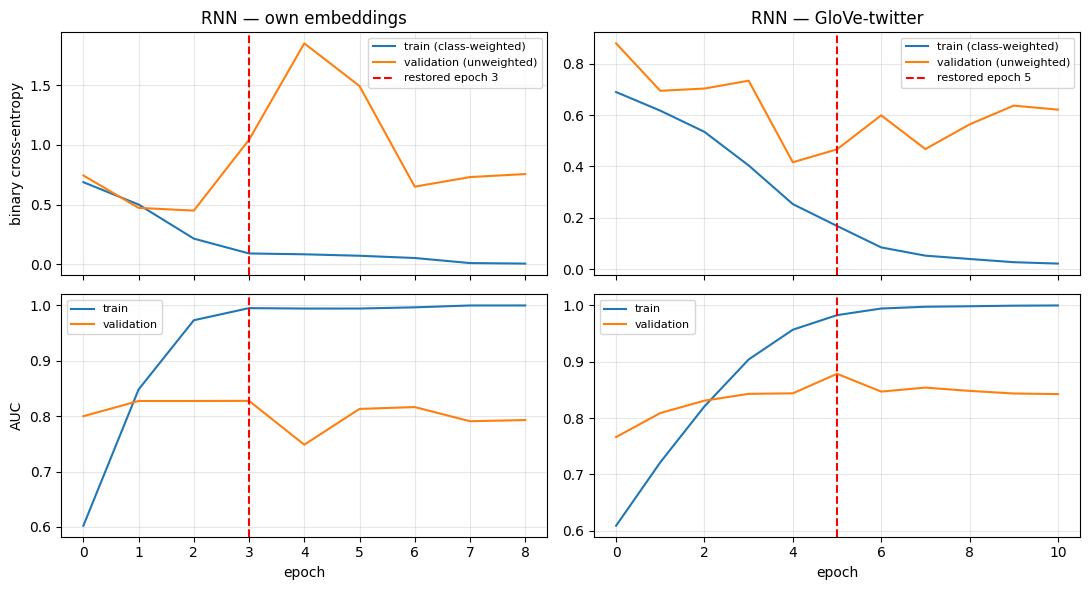

own    epochs run  9   best val AUC 0.8277 at epoch 3   (val_loss would have stopped at epoch 2)
GloVe  epochs run 11   best val AUC 0.8784 at epoch 5   (val_loss would have stopped at epoch 4)


In [33]:
# Training curves for both variants, each with its own tuned config, on the Tier-1 split.
_, story_own = train_rnn(X_rnn_train[idx_fit], y_train[idx_fit], X_rnn_train[idx_val],
                         return_history=True, **RNN_CFG)
_, story_glove = train_rnn(X_rnn_train[idx_fit], y_train[idx_fit], X_rnn_train[idx_val],
                           glove=glove, return_history=True, **GLOVE_CFG)

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex="col")
for col, (story, title) in enumerate([(story_own, "own embeddings"),
                                      (story_glove, "GloVe-twitter")]):
    best = int(np.argmax(story.history["val_auc"]))  # the epoch early stopping restores

    ax = axes[0, col]
    ax.plot(story.history["loss"], label="train (class-weighted)")
    ax.plot(story.history["val_loss"], label="validation (unweighted)")
    ax.axvline(best, color="red", linestyle="--", linewidth=1.5, label=f"restored epoch {best}")
    ax.set_title(f"RNN — {title}")
    ax.set_ylabel("binary cross-entropy" if col == 0 else "")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.plot(story.history["auc"], label="train")
    ax.plot(story.history["val_auc"], label="validation")
    ax.axvline(best, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("epoch")
    ax.set_ylabel("AUC" if col == 0 else "")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for name, story in [("own", story_own), ("GloVe", story_glove)]:
    va, vl = story.history["val_auc"], story.history["val_loss"]
    print(f"{name:6s} epochs run {len(va):2d}   best val AUC {max(va):.4f} at epoch {int(np.argmax(va))}"
          f"   (val_loss would have stopped at epoch {int(np.argmin(vl))})")


*The train line is class-weighted and `val_loss` is not, so part of the vertical offset is that
asymmetry rather than generalisation error — read where the curves diverge, not the size of the
gap. The dashed line marks the epoch `restore_best_weights` returns to.*


**GloVe helps, but not decisively.** CV macro-F1 **0.7224 ± 0.0335** with pre-trained vectors
against **0.7030 ± 0.0289** learned from scratch — a gap of 0.019, inside either fold spread.
Test macro-F1 (0.7605 vs 0.7336) and ROC-AUC (0.881 vs 0.836) point the same way. GloVe covers
85.1 % of the training vocabulary, and both searches chose to fine-tune rather than freeze.

Both RNNs land below the best TF-IDF model (0.7325 ± 0.0337).


In [34]:
# §8-§9 hold several transformers in memory at once, so release what §7 no longer needs:
# the GloVe vectors alone are ~1 GB resident. Written to be safe to re-run.
for _name in ("glove", "_vec_full", "story_own", "story_glove"):
    globals().pop(_name, None)
keras.backend.clear_session()
print(f"released GloVe and Keras session; {gc.collect()} objects collected")


released GloVe and Keras session; 0 objects collected


### **8. Pre-trained transformer, applied zero-shot**

Two publicly available sentiment models, run on `clean_transformer` text without any training on
our labels:

- **`cardiffnlp/twitter-roberta-base-sentiment-latest`** — RoBERTa pre-trained on ~124 M tweets
  and fine-tuned for sentiment. Its own preprocessing convention is the one §3 reproduces.
- **`ElKulako/cryptobert`** — pre-trained on crypto social-media posts and fine-tuned for
  Bearish / Neutral / Bullish, so it matches both the register and the domain.

Both emit three classes against our two. We drop the neutral mass and score
`p(positive) / (p(positive) + p(negative))`, then calibrate the threshold on out-of-fold scores
like every other model. Neither is fitted, so their out-of-fold scores are their scores on the
training tweets.


In [35]:
from transformers import pipeline

X_trf_train, X_trf_test = TEXTS["transformer"]
ZERO_SHOT = {
    "Twitter-RoBERTa": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "CryptoBERT": "ElKulako/cryptobert",
}
# Label vocabularies differ between the two checkpoints; map each onto pos / neg / neutral.
POS_LABELS = {"positive", "label_2", "bullish"}
NEG_LABELS = {"negative", "label_0", "bearish"}
ZS_PROBS: dict[str, tuple] = {}   # raw 3-class probabilities, kept for the diagnostic below


def zero_shot_probs(model_name: str, texts: np.ndarray, batch_size: int = 64) -> np.ndarray:
    """Full class-probability matrix, columns ordered (negative, neutral, positive)."""
    clf = pipeline("text-classification", model=model_name, top_k=None,
                   device=DEVICE, truncation=True, max_length=64)
    labels = {lab.lower() for lab in clf.model.config.id2label.values()}
    if not (labels & POS_LABELS) or not (labels & NEG_LABELS):
        raise ValueError(f"unmapped label set for {model_name}: {labels}")

    out = clf(list(texts), batch_size=batch_size)
    del clf

    def order(row):
        d = {r["label"].lower(): r["score"] for r in row}
        neg = sum(v for k, v in d.items() if k in NEG_LABELS)
        pos = sum(v for k, v in d.items() if k in POS_LABELS)
        return [neg, 1.0 - neg - pos, pos]

    return np.array([order(r) for r in out])


def to_binary_score(probs: np.ndarray) -> np.ndarray:
    """P(positive) renormalised against P(negative), discarding the neutral mass."""
    neg, pos = probs[:, 0], probs[:, 2]
    return pos / (pos + neg)


In [36]:
# Long-running cell on first use: each checkpoint is a ~500 MB download, cached afterwards.
for label, model_name in ZERO_SHOT.items():
    _t0 = time.time()
    ZS_PROBS[label] = (zero_shot_probs(model_name, X_trf_train),
                       zero_shot_probs(model_name, X_trf_test))
    print(f"{label} scored 2000 tweets in {time.time() - _t0:.0f}s")
    record(f"Zero-shot — {label}",
           to_binary_score(ZS_PROBS[label][0]), to_binary_score(ZS_PROBS[label][1]))


Twitter-RoBERTa scored 2000 tweets in 20s
Zero-shot — Twitter-RoBERTa  CV macro-F1 0.9835 ± 0.0070   |   test macro-F1 0.9805   ROC-AUC 0.9988   thr +0.518
CryptoBERT scored 2000 tweets in 18s
Zero-shot — CryptoBERT       CV macro-F1 0.5971 ± 0.0242   |   test macro-F1 0.5847   ROC-AUC 0.6821   thr +0.984


Twitter-RoBERTa scores far above every model trained on the labels, which is not what zero-shot
transfer normally looks like. The next cell tests two explanations: that the labels were produced
by this model, and that the tweets were memorised from its training data.


In [37]:
# Can a fixed decision rule on Twitter-RoBERTa's raw outputs reconstruct the labels?
probs_all = np.vstack(ZS_PROBS["Twitter-RoBERTa"])
y_all = np.concatenate([y_train, y_test])

for name, pred in [("argmax over the 3 classes", (probs_all.argmax(1) != 0).astype(int)),
                   ("p(positive) > p(negative)", (probs_all[:, 2] > probs_all[:, 0]).astype(int))]:
    agree = (pred == y_all).mean()
    print(f"{name:28s} reproduces {agree:.4f} of all 2000 labels "
          f"({(pred != y_all).sum()} mismatches)")

# Could the model instead have memorised these tweets during training? Twitter IDs are snowflakes,
# so they carry a timestamp: ms since epoch = (id >> 22) + 1288834974657.
ids = np.concatenate([train.index.values, test.index.values]).astype("int64")
posted = pd.to_datetime((ids >> 22) + 1288834974657, unit="ms", utc=True)
print(f"\ntweets posted between {posted.min():%Y-%m-%d} and {posted.max():%Y-%m-%d}"
      f"   (checkpoint trained on tweets up to December 2021)")


argmax over the 3 classes    reproduces 0.8970 of all 2000 labels (206 mismatches)
p(positive) > p(negative)    reproduces 0.9890 of all 2000 labels (22 mismatches)

tweets posted between 2023-03-30 and 2023-03-31   (checkpoint trained on tweets up to December 2021)


**The labels were probably generated by this model.** The rule `p(positive) > p(negative)`
reproduces **98.9 %** of all 2 000 labels, while the model's own 3-class argmax reproduces only
89.7 % — memorised training labels would show the opposite ordering, since what a model memorises
is its class decision rather than a two-way probability comparison. The dates make memorisation
unlikely in any case: these tweets are from March 2023 and the checkpoint was trained on tweets up
to December 2021.

On that reading Twitter-RoBERTa is largely reproducing the labelling rule rather than being
benchmarked against it, so its row is not a target the other models could realistically reach. It
would also explain §2: the rule discards the neutral class, so neutral-leaning tweets end up
labelled positive.

**CryptoBERT** (0.5971 ± 0.0242) is the informative zero-shot row: despite matching both register
and domain it transfers poorly, and its calibrated threshold sits at 0.984 — its Bullish/Bearish
axis is not the axis these labels encode.


### **9. Fine-tuned transformer**

Base checkpoint: **`distilbert/distilbert-base-uncased-finetuned-sst-2-english`**. Two properties
make it the right size for this problem. It is distilled from BERT-base, so at 67 M parameters it
fine-tunes in minutes where a full encoder would spend most of its capacity unused on 1 500
examples. And it already carries a trained binary sentiment head, so training starts from
sentiment features rather than from raw language modelling and converges within a few epochs.

Given §8, what this section measures is how much of Twitter-RoBERTa's labelling behaviour a
smaller distilled model can absorb from 1 500 examples.

**Search.** Optuna TPE on the Tier-1 split, as in §6 and §7, over learning rate, number of
epochs, batch size, warmup fraction, weight decay, and whether the loss is class-weighted.
Epochs matter here because — unlike the RNNs — there is no early stopping to end training, so it
is the only control over under- and over-fitting.

Implementation notes: a plain `torch.utils.data.Dataset` keeps the `datasets` package out of the
requirements. Nothing is written to disk — `save_strategy="no"` throughout, and predictions are
taken from the in-memory model.


In [38]:
import math
import shutil
import tempfile

from torch.utils.data import Dataset as TorchDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from transformers.trainer_callback import PrinterCallback

FT_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
FT_MAX_LEN = 64          # §2: no tweet exceeds 59 words
FT_OUTPUT_DIR = tempfile.mkdtemp(prefix="hf_trainer_")

ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL)
print(f"{FT_MODEL}\n  labels {AutoModelForSequenceClassification.from_pretrained(FT_MODEL).config.id2label}"
      f"   scratch dir {FT_OUTPUT_DIR}")


class TweetDataset(TorchDataset):
    """Minimal torch dataset, so Trainer works without adding `datasets` to the requirements."""

    def __init__(self, texts, labels=None):
        self.enc = ft_tokenizer(list(texts), truncation=True, padding="max_length",
                                max_length=FT_MAX_LEN)
        self.labels = labels

    def __len__(self):
        return len(self.enc["input_ids"])

    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(int(self.labels[i]))
        return item


class WeightedTrainer(Trainer):
    """Trainer with a class-weighted cross-entropy, matching the RNNs' treatment of the 4:1 split."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weight = None if self.class_weights is None else self.class_weights.to(outputs.logits.device)
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


distilbert/distilbert-base-uncased-finetuned-sst-2-english
  labels {0: 'NEGATIVE', 1: 'POSITIVE'}   scratch dir /var/folders/v5/72f66vs1133dr6d7cfwwyxm40000gn/T/hf_trainer_pp0ibzbn


In [39]:
def train_distilbert(X_tr, y_tr, X_va, lr=3e-5, epochs=3, batch_size=16, warmup=0.1,
                     weight_decay=0.01, weighted=False) -> np.ndarray:
    """Fine-tune the distilled SST-2 checkpoint on one fold and return P(positive) for X_va."""
    torch.manual_seed(SEED)
    os.makedirs(FT_OUTPUT_DIR, exist_ok=True)   # the last cell of §9 removes it again
    model = AutoModelForSequenceClassification.from_pretrained(FT_MODEL, num_labels=2)

    total_steps = math.ceil(len(X_tr) / batch_size) * epochs
    args = TrainingArguments(
        output_dir=FT_OUTPUT_DIR,
        eval_strategy="no", save_strategy="no", logging_strategy="no", report_to=[],
        per_device_train_batch_size=batch_size, per_device_eval_batch_size=64,
        learning_rate=lr, num_train_epochs=epochs,
        warmup_steps=max(1, int(warmup * total_steps)),   # warmup_ratio is deprecated in v5
        weight_decay=weight_decay, seed=SEED, disable_tqdm=True,
        dataloader_pin_memory=False,   # unsupported on MPS, and warns once per dataloader
    )
    weights = (torch.tensor([CLASS_WEIGHT[0], CLASS_WEIGHT[1]], dtype=torch.float)
               if weighted else None)
    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=TweetDataset(X_tr, y_tr),
        processing_class=ft_tokenizer, class_weights=weights,
    )
    trainer.remove_callback(PrinterCallback)   # otherwise every fit prints a metrics dict
    trainer.train()

    logits = trainer.predict(TweetDataset(X_va)).predictions
    # Softmax in numpy, not torch: torch, scikit-learn and xgboost each load their own OpenMP
    # runtime, and torch's CPU softmax can deadlock in an OpenMP barrier on macOS.
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = (exp / exp.sum(axis=1, keepdims=True))[:, 1]

    del trainer, model
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return probs


In [40]:
# Long-running cell: each trial is a full fine-tune on the Tier-1 split.
FT_TRIALS = 15


def ft_objective(trial: optuna.Trial) -> float:
    """Calibrated macro-F1 on the Tier-1 validation split for one fine-tuning configuration."""
    cfg = {
        "lr": trial.suggest_float("lr", 1e-5, 8e-5, log=True),
        "epochs": trial.suggest_int("epochs", 2, 4),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32]),
        "warmup": trial.suggest_float("warmup", 0.0, 0.2),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        "weighted": trial.suggest_categorical("weighted", [False, True]),
    }
    s = train_distilbert(X_trf_train[idx_fit], y_train[idx_fit], X_trf_train[idx_val], **cfg)
    return f1_score(y_train[idx_val], (s > tune_threshold(y_train[idx_val], s)).astype(int),
                    average="macro")


_t0 = time.time()
ft_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
ft_study.optimize(ft_objective, n_trials=FT_TRIALS)
FT_CFG = dict(ft_study.best_params)

print(f"{FT_TRIALS} trials in {(time.time() - _t0) / 60:.1f} min")
print(f"best val macro-F1 {ft_study.best_value:.4f}")
print(f"config {FT_CFG}")
print(f"trial spread: min {min(t.value for t in ft_study.trials):.4f}  "
      f"median {np.median([t.value for t in ft_study.trials]):.4f}  "
      f"max {ft_study.best_value:.4f}")


15 trials in 23.3 min
best val macro-F1 0.8139
config {'lr': 3.49028546063e-05, 'epochs': 4, 'batch_size': 32, 'warmup': 0.16648852816008436, 'weight_decay': 0.021233911067827616, 'weighted': True}
trial spread: min 0.7778  median 0.8061  max 0.8139


In [41]:
# Long-running cell: 5-fold CV plus a final fine-tune on all 1500.
_t0 = time.time()
oof_ft = cv_oof(
    lambda X_tr, y_tr, X_va: train_distilbert(X_tr, y_tr, X_va, **FT_CFG), X_trf_train
)
test_ft = train_distilbert(X_trf_train, y_train, X_trf_test, **FT_CFG)
record("Fine-tuned DistilBERT", oof_ft, test_ft)
print(f"({(time.time() - _t0) / 60:.1f} min)")

shutil.rmtree(FT_OUTPUT_DIR, ignore_errors=True)   # scratch dir


Fine-tuned DistilBERT        CV macro-F1 0.8054 ± 0.0222   |   test macro-F1 0.8034   ROC-AUC 0.9229   thr +0.927
(10.5 min)


**The fine-tune leads every model trained on these labels.** CV macro-F1 **0.8054 ± 0.0222**
against **0.7325 ± 0.0337** for the best TF-IDF model — a gap of 0.073, roughly twice the larger
fold spread, and it holds on the test set (0.8034 vs 0.7873).

**The configuration barely matters.** The 15 trials span 0.7778 to 0.8139 with a median of
0.8061, so the best configuration sits well under one fold-standard-deviation above a typical
one. Starting from a checkpoint that already has a sentiment head leaves little for these
hyperparameters to decide.

Against Twitter-RoBERTa's 0.9835, 1 500 examples recover much of its behaviour but not all of it.


### **10. Results**

Every row comes from the single `RESULTS` store, so all figures were produced under the §4
protocol: threshold calibrated on out-of-fold scores, test set touched once.

The **Twitter-RoBERTa** row is listed separately rather than ranked — §8 suggests it largely
reproduces the rule that produced the labels, so it describes the labels rather than competing
with the other models.


In [42]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve

ANNOTATOR = "Zero-shot — Twitter-RoBERTa"

metrics_table = (
    pd.DataFrame({name: {k: v for k, v in r.items() if not k.startswith("_")}
                  for name, r in RESULTS.items()}).T
    .rename(columns={"Macro-F1": "Test macro-F1"})
    [["CV macro-F1", "CV std", "Test macro-F1", "Accuracy", "Balanced acc", "Precision (neg)",
      "Recall (neg)", "F1 (neg)", "ROC-AUC", "PR-AUC (neg)", "Threshold"]]
    .astype(float)
)

ranked = metrics_table.drop(index=ANNOTATOR).sort_values("CV macro-F1", ascending=False)
final_table = pd.concat([ranked, metrics_table.loc[[ANNOTATOR]]]).round(4)
final_table


,CV macro-F1,CV std,Test macro-F1,Accuracy,Balanced acc,Precision (neg),Recall (neg),F1 (neg),ROC-AUC,PR-AUC (neg),Threshold
Fine-tuned DistilBERT,0.8054,0.0222,0.8034,0.870,0.8243,0.6372,0.7500,0.6890,0.9229,0.8027,0.9271
TF-IDF + LinearSVC,0.7325,0.0337,0.7873,0.868,0.7873,0.6562,0.6562,0.6562,0.8817,0.6095,0.1190
TF-IDF + LogReg,0.7282,0.0405,0.7738,0.852,0.7893,0.6000,0.6875,0.6408,0.8855,0.6217,0.5917
RNN — GloVe-twitter,0.7224,0.0335,0.7605,0.858,0.7493,0.6471,0.5729,0.6077,0.8810,0.6444,0.1194
Lexicon — VADER,0.7036,0.0269,0.7008,0.828,0.6871,0.5641,0.4583,0.5057,0.7658,0.4565,-0.0082
RNN — own embeddings,0.7030,0.0289,0.7336,0.840,0.7263,0.5909,0.5417,0.5652,0.8363,0.5273,0.3116
TF-IDF + XGBoost,0.6796,0.0216,0.6741,0.772,0.7001,0.4308,0.5833,0.4956,0.7980,0.5593,0.4913
Lexicon — Loughran-McDonald,0.6475,0.0413,0.6408,0.778,0.6403,0.4211,0.4167,0.4188,0.6809,0.3414,-0.2000
Zero-shot — CryptoBERT,0.5971,0.0242,0.5847,0.704,0.6024,0.3088,0.4375,0.3621,0.6821,0.3146,0.9840
Majority class,0.4485,0.0000,0.4469,0.808,0.5000,0.0000,0.0000,0.0000,0.5000,0.1920,0.5000


*Last row: the model that most likely produced the labels, shown for reference rather than ranked.*


#### Three findings from the table

**Accuracy hides the baseline.** The majority baseline reaches 0.808 accuracy, above CryptoBERT
(0.704), Loughran-McDonald (0.778) and XGBoost (0.772), while its macro-F1 of 0.4469 is the worst
in the table. The top of the ranking looks similar under either metric, but accuracy alone cannot
tell a working model from one that never predicts the negative class.

**Only the fine-tuned transformer separates clearly.** DistilBERT's 0.8054 ± 0.0222 sits about two
fold-standard-deviations above the next model. The four entries between 0.70 and 0.74 (LinearSVC,
LogReg, RNN-GloVe, VADER) fall within one standard deviation of each other, so their order should
not be read as a ranking.

**PR-AUC spreads the models out more than ROC-AUC.** Higher is better for both, but they disagree
about how much: LinearSVC and the GloVe RNN have almost the same ROC-AUC (0.8817 and 0.8810) yet
noticeably different PR-AUC (0.6095 and 0.6444), and DistilBERT leads the field by 0.037 on
ROC-AUC against 0.158 on PR-AUC. PR-AUC only counts performance on the negative class, which is
the part every model here finds hard.


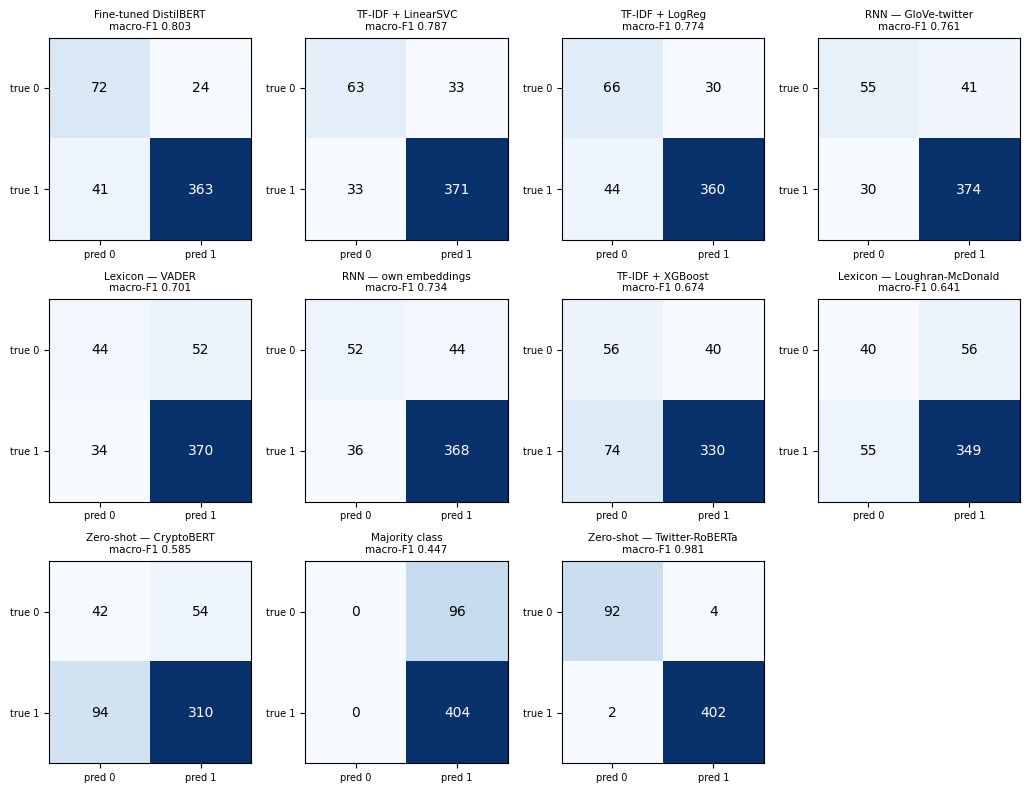

In [43]:
# Confusion matrices on the test set, each at its own calibrated threshold.
order = list(final_table.index)
ncol = math.ceil(len(order) / 3)
fig, axes = plt.subplots(3, ncol, figsize=(2.6 * ncol, 8))
for ax, name in zip(axes.ravel(), order):
    r = RESULTS[name]
    cm = confusion_matrix(y_test, (r["_test"] > r["Threshold"]).astype(int))
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", fontsize=10,
                color="white" if v > cm.max() / 2 else "black")
    ax.set_title(f"{name}\nmacro-F1 {r['Macro-F1']:.3f}", fontsize=7.5)
    ax.set_xticks([0, 1], ["pred 0", "pred 1"], fontsize=7)
    ax.set_yticks([0, 1], ["true 0", "true 1"], fontsize=7)
for ax in axes.ravel()[len(order):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


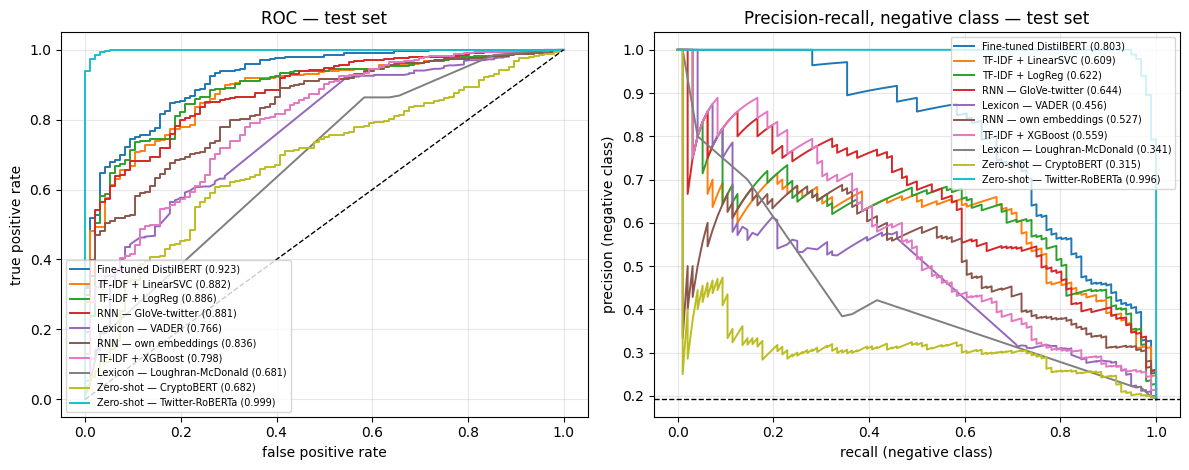

In [44]:
# ROC and precision-recall. PR is on the negative class, the minority one at 19 % prevalence.
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4.8))
for name in order:
    if name == "Majority class":
        continue
    s = RESULTS[name]["_test"]
    fpr, tpr, _ = roc_curve(y_test, s)
    ax_roc.plot(fpr, tpr, lw=1.4, label=f"{name} ({RESULTS[name]['ROC-AUC']:.3f})")
    prec, rec, _ = precision_recall_curve(1 - y_test, -s)
    ax_pr.plot(rec, prec, lw=1.4, label=f"{name} ({RESULTS[name]['PR-AUC (neg)']:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
ax_roc.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC — test set")
ax_pr.axhline(1 - y_test.mean(), color="k", ls="--", lw=1)
ax_pr.set(xlabel="recall (negative class)", ylabel="precision (negative class)",
          title="Precision-recall, negative class — test set")
for ax in (ax_roc, ax_pr):
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="lower left" if ax is ax_roc else "upper right")
plt.tight_layout()
plt.show()


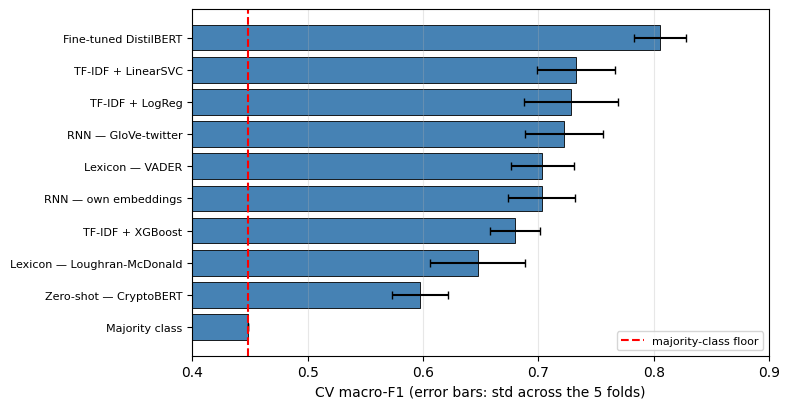

In [45]:
# Which differences survive the fold-to-fold spread?
rows = list(ranked.index)[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(range(len(rows)), ranked.loc[rows, "CV macro-F1"], xerr=ranked.loc[rows, "CV std"],
        capsize=3, color="steelblue", edgecolor="black", linewidth=0.6)
ax.axvline(RESULTS["Majority class"]["CV macro-F1"], color="red", ls="--", lw=1.5,
           label="majority-class floor")
ax.set_yticks(range(len(rows)), rows, fontsize=8)
ax.set_xlabel("CV macro-F1 (error bars: std across the 5 folds)")
ax.set_xlim(0.4, 0.9)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### **11. Submission artefacts**

`requirements.txt` is written from the versions actually loaded in this kernel, so it cannot
drift from what the notebook was run with. Beyond the course environment it needs two additions:
`pyarrow` (the data ships as parquet) and `accelerate` (required by the Hugging Face `Trainer`).


In [46]:
from importlib.metadata import version
from pathlib import Path

# Everything the notebook imports, plus pyarrow (parquet) and accelerate (Trainer).
REQUIRED = ["numpy", "pandas", "pyarrow", "scipy", "scikit-learn", "matplotlib",
            "nltk", "emoji", "pysentiment2", "gensim",
            "keras", "tensorflow", "torch", "transformers", "accelerate",
            "xgboost", "optuna"]

# setuptools relevant when using conda package manager.
lines = [f"# Python {sys.version.split()[0]}", "setuptools<81"]
lines += [f"{pkg}=={version(pkg)}" for pkg in REQUIRED]
Path("requirements.txt").write_text("\n".join(lines) + "\n")
print("requirements.txt created :-)")

requirements.txt created :-)
